# Notebook 3: TF-IDF Doctor Retriever
## Building a Medical Search Engine from Patient Reviews

---

In our previous notebooks (**EDA** and **Preprocessing**), we explored the raw patient reviews and turned them into clean, tokenized text.

Now we'll use that clean text to build a **search engine**: given a medical query like `سنگ کلیه` (kidney stones), find the **most relevant doctors**.

### Roadmap

| Part | Topic |
|------|-------|
| **0** | Setup & Loading the Preprocessed Data |
| **1** | TF-IDF Theory — From Scratch |
| **2** | Building the Doctor Corpus |
| **3** | Building the TF-IDF Index |
| **4** | Query Preprocessing |
| **5** | Retrieval (Top-K Search) |
| **6** | Recommendation-Aware Reranking |
| **7** | Holdout Evaluation |
| **8** | Qualitative Test Suite |
| **9** | Medical Stopword Pipeline |
| **10** | Summary & Next Steps |

---
# Part 0: Setup & Data Loading
---

## What is Information Retrieval?

**Information Retrieval (IR)** = finding documents *relevant* to a user's query from a large collection.

```
Query: "سنگ کلیه"   →   IR System   →   Ranked list of relevant DOCTORS
```

**How is this different from a database query?**
- A database does *exact matching* (`WHERE specialty = 'urology'`).
- An IR system does *semantic relevance*: a doctor whose patients keep talking about kidney stones is relevant — even if the exact word *urologist* never appears in the reviews.

The core idea: turn both the query and each document into a **vector**, then measure their **similarity**.

## 0.1 Imports

In [49]:
# Uncomment to install if needed:
#!pip install pandas numpy scikit-learn matplotlib

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Keep matplotlib titles/labels in English (avoids Farsi font issues).
# Farsi inside print() and DataFrames is fine.
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': 0.3})
print('Imports OK ✓')

Imports OK ✓


## 0.2 Load the Data

We load two files:

1. **Cleaned comments** — the output of our **preprocessing** notebook. Each row is one comment, already tokenized and stopword-filtered.
2. **Doctor metadata** — names and specialties (used only for displaying results).

In [51]:
# 1) Cleaned comments (output of the preprocessing notebook)
comments_df = pd.read_csv('comments_for_tfidf_retriever.csv', keep_default_na=False)
comments_df['doctor_id'] = comments_df['doctor_id'].astype(str)
comments_df['final_preprocessed_text'] = comments_df['final_preprocessed_text'].astype(str)

print(f'Comments: {len(comments_df):,} | Doctors: {comments_df["doctor_id"].nunique():,}')
comments_df.head(3)

Comments: 66,464 | Doctors: 545


,doctor_id,final_preprocessed_text,text_step04,rate,label,date,tok_all_count,tok_nostop_count,is_placeholder_negative
0,100246,حاذق,بسیار حاذق,5.0,1,۱۴۰۳/۰۸/۰۴,2,1,False
1,100246,زگیل ناخن درمانم,زگیل زیر ناخن تحت درمانم,5.0,1,۱۴۰۰/۰۲/۰۶,5,3,False
2,100246,درود تشخیص درست خارش بدن ودرمان,درود تشخیص درست خارش بدن ودرمان عالی,5.0,1,۱۴۰۴/۰۹/۲۸,7,6,False


In [52]:
# 2) Doctor metadata (from raw dataset — used only to show names/specialties)
doctors_df = pd.read_csv('doctors_raw_canonical.csv', keep_default_na=False)
doctors_df['doctor_id'] = doctors_df['doctor_id'].astype(str)

# Quick lookup dictionaries: doctor_id → name / specialty
name_map      = dict(zip(doctors_df['doctor_id'], doctors_df.get('name', '')))
specialty_map = dict(zip(doctors_df['doctor_id'], doctors_df.get('specialty', '')))

print(f'Doctors: {len(doctors_df):,}')
doctors_df.head(3)

Doctors: 569


,doctor_id,source_file,profile_url,nice_id,name,specialty,medical_code,verified,followers_count,reviews_count,rating_percent,rating_score_5,biography,office_count,comments_count_in_file,selected_source_file,all_source_files,source_files_count
0,100246,پوست_و_مو_doctor_337.json,https://nobat.ir/3023,3023,دکتر علیرضا تقی زاده,متخصص پوست ، مو و زیبایی,متخصصشماره نظام: ۴۸۸۷۵,False,,205,86,4.3,,1,134,پوست_و_مو_doctor_337.json,پوست_و_مو_doctor_337.json,1
1,100332,ارتوپدی_doctor_203.json,https://nobat.ir/doctor/%D8%AF%DA%A9%D8%AA%D8%...,3034,دکتر کورش فاتح,متخصص ارتوپدی - تعویض مفصل,متخصصشماره نظام: ۴۲۲۶۸,False,,256,86,4.3,,3,169,ارتوپدی_doctor_203.json,ارتوپدی_doctor_203.json,1
2,102091,پوست_و_مو_doctor_369.json,https://nobat.ir/dresfahani,dresfahani,دکتر منصور اصفهانی,متخصص پوست ، مو و لیزر,متخصصشماره نظام: ۳۲۲۸۲,False,,464,90,4.5,اینجانب دکتر منصور اصفهانی متولد شهر زیبای رشت...,2,257,پوست_و_مو_doctor_369.json,پوست_و_مو_doctor_369.json,1


### Part 0 Summary
✅ Loaded the cleaned comments and the doctor metadata.  
✅ Built `name_map` and `specialty_map` for displaying results later.

**Next:** before using any library, let's build TF-IDF from scratch to deeply understand it.

---
# Part 1: Understanding TF-IDF (from scratch)
---

We'll build TF-IDF **by hand** on a tiny corpus, then verify our results against `sklearn`.

Steps:
1. Compute **TF** manually  
2. Compute **IDF** manually  
3. Compute **TF-IDF** + **L2-normalize**  
4. Compute **Cosine Similarity** for a query  
5. Verify against `sklearn`  
6. Two production tweaks: **Sublinear TF** and **Bigrams**

## 1.1 The Problem: How to Compare Text?

Patient query: **`سنگ کلیه`** (kidney stones). We have 4 doctor profiles:

| Doctor | Comment |
|--------|---------|
| Doc 0 | `سنگ کلیه درد سنگ` *(kidney stone pain — "سنگ" twice)* |
| Doc 1 | `سنگ مثانه درمان` *(bladder stone treatment)* |
| Doc 2 | `دکتر خوب عالی` *(good doctor — irrelevant)* |
| Doc 3 | `درد کمر دیسک درد` *(back pain disc — "درد" twice)* |

Intuitively, **Doc 0** is the best match. **Doc 1** shares only `سنگ`. **Docs 2 & 3** are unrelated to kidneys.

How do we teach a computer to figure this out?  
→ Turn each document into a **vector of numbers**, then compare vectors mathematically.

## 1.2 Term Frequency (TF)

**TF(t, d)** = how many times term `t` appears in document `d`. Just a word count.

In [53]:
# Tiny corpus — already tokenized (words separated by spaces)
corpus = [
    'سنگ کلیه درد سنگ',     # Doc 0
    'سنگ مثانه درمان',       # Doc 1
    'دکتر خوب عالی',         # Doc 2
    'درد کمر دیسک درد',      # Doc 3
]
tokenized = [doc.split() for doc in corpus]
vocab = sorted({w for d in tokenized for w in d})

# TF matrix: one row per doc, one column per term
tf = pd.DataFrame([[Counter(d).get(t, 0) for t in vocab] for d in tokenized],
                  columns=vocab, index=[f'Doc {i}' for i in range(len(corpus))])
print(f'Vocabulary ({len(vocab)} terms): {vocab}')
tf

Vocabulary (10 terms): ['خوب', 'درد', 'درمان', 'دکتر', 'دیسک', 'سنگ', 'عالی', 'مثانه', 'کلیه', 'کمر']


,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0,1,0,0,0,2,0,0,1,0
Doc 1,0,0,1,0,0,1,0,1,0,0
Doc 2,1,0,0,1,0,0,1,0,0,0
Doc 3,0,2,0,0,1,0,0,0,0,1


### What's wrong with raw TF?
- Common words like `درد` (pain) appear everywhere — high count, **low information**.
- A long document beats a short one on every word, just because it has more text.

→ We need to **down-weight common words**. That's the job of **IDF**.

## 1.3 Inverse Document Frequency (IDF)

$$\text{IDF}(t) = \log\!\left(\frac{1+N}{1+\text{df}(t)}\right) + 1$$

- **N** = total documents  
- **df(t)** = number of documents containing term `t`

**Intuition:** a term in *every* doc → IDF ≈ 1 (uninformative). A term in *only one* doc → IDF is high (very informative).

> The `+1`s are **smoothing** — they avoid division by zero and prevent IDF from being exactly 0.

In [54]:
N = len(corpus)
df = {t: sum(t in d for d in tokenized) for t in vocab}
idf = {t: round(np.log((1+N)/(1+df[t])) + 1, 4) for t in vocab}

pd.DataFrame({'df': df, 'IDF': idf}).sort_values('IDF', ascending=False)

,df,IDF
خوب,1,1.9163
درمان,1,1.9163
کلیه,1,1.9163
دکتر,1,1.9163
دیسک,1,1.9163
عالی,1,1.9163
کمر,1,1.9163
مثانه,1,1.9163
درد,2,1.5108
سنگ,2,1.5108


## 1.4 TF × IDF + L2 Normalization

Multiply each TF cell by its IDF, then normalize each row to unit length:

$$\text{TF-IDF}(t,d) = \text{TF}(t,d) \times \text{IDF}(t), \qquad \hat{v} = \frac{v}{\|v\|_2}$$

**Why L2-normalize?** So a long document and a short one are compared *fairly* — we measure *direction* (what the doc is about), not *magnitude* (how much text it has).

In [55]:
# 1) TF × IDF
raw = tf.values * np.array([idf[t] for t in vocab])

# 2) L2-normalize each row
norms = np.linalg.norm(raw, axis=1, keepdims=True)
norms[norms == 0] = 1.0
tfidf = raw / norms

pd.DataFrame(np.round(tfidf, 3), columns=vocab, index=tf.index)

,خوب,درد,درمان,دکتر,دیسک,سنگ,عالی,مثانه,کلیه,کمر
Doc 0,0.000,0.389,0.000,0.000,0.000,0.778,0.000,0.000,0.493,0.000
Doc 1,0.000,0.000,0.618,0.000,0.000,0.487,0.000,0.618,0.000,0.000
Doc 2,0.577,0.000,0.000,0.577,0.000,0.000,0.577,0.000,0.000,0.000
Doc 3,0.000,0.744,0.000,0.000,0.472,0.000,0.000,0.000,0.000,0.472


## 1.5 Cosine Similarity

$$\cos\_sim(q, d) = \frac{q \cdot d}{\|q\| \, \|d\|}$$

Since our vectors are already L2-normalized, cosine similarity is just the **dot product**: `q · d`.

- **1.0** → same direction (perfectly similar)  
- **0.0** → no shared terms

**Why cosine and not Euclidean distance?** Cosine focuses on *direction* (topic), not *magnitude* (document length).

In [56]:
# Build query vector with the same vocab and IDF, then L2-normalize
query = 'سنگ کلیه'
qc = Counter(query.split())
q = np.array([qc.get(t, 0) * idf[t] for t in vocab], dtype=float)
q /= (np.linalg.norm(q) or 1.0)

sims = tfidf @ q   # cosine sim = dot product (vectors are normalized)

pd.DataFrame({'text': corpus, 'cosine_sim': np.round(sims, 4)}) \
  .sort_values('cosine_sim', ascending=False)

,text,cosine_sim
0,سنگ کلیه درد سنگ,0.8691
1,سنگ مثانه درمان,0.3015
2,دکتر خوب عالی,0.0000
3,درد کمر دیسک درد,0.0000


As expected, **Doc 0** (`سنگ کلیه درد سنگ`) wins by a clear margin. ✅

## 1.6 Verification with sklearn

Let's confirm our manual numbers match `sklearn.TfidfVectorizer`.

In [57]:
vec = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None,
                      norm='l2', sublinear_tf=False)
X = vec.fit_transform(corpus)
sklearn_sims = cosine_similarity(vec.transform([query]), X).ravel()

pd.DataFrame({'manual': np.round(sims, 4),
              'sklearn': np.round(sklearn_sims, 4),
              'match': np.isclose(sims, sklearn_sims, atol=1e-3)})

,manual,sklearn,match
0,0.8691,0.8691,True
1,0.3015,0.3015,True
2,0.0000,0.0000,True
3,0.0000,0.0000,True


## 1.7 Production Tweak #1 — Sublinear TF

Raw TF is too aggressive: a word appearing 100× is treated as 100× more important than appearing once. In reality, the *first* mention is most informative — extra mentions add diminishing value.

$$\text{tf}_{\text{sub}}(t,d) = 1 + \log(\text{tf}(t,d)) \quad \text{if tf} > 0$$

This **compresses** high counts (e.g., tf=100 → 5.6 instead of 100).

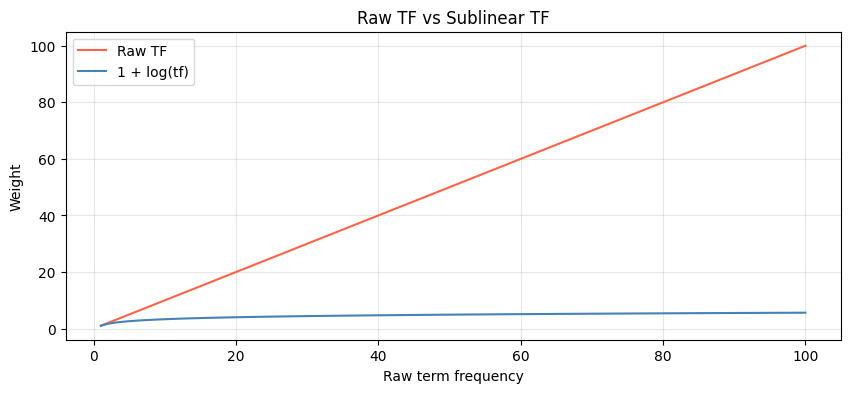

In [58]:
tfs = np.arange(1, 101)
plt.plot(tfs, tfs, label='Raw TF', color='tomato')
plt.plot(tfs, 1 + np.log(tfs), label='1 + log(tf)', color='steelblue')
plt.xlabel('Raw term frequency'); plt.ylabel('Weight')
plt.title('Raw TF vs Sublinear TF'); plt.legend(); plt.show()

## 1.8 Production Tweak #2 — Bigrams

With unigrams only, the query `سنگ کلیه` is matched as two independent words — so a doc about `سنگ صفرا` (gallstone) gets credit for `سنگ`.

Adding **bigrams** (`ngram_range=(1, 2)`) lets the model treat `سنگ کلیه` as a single feature — much more specific.

In [59]:
docs = ['سنگ کلیه درد شدید', 'سنگ صفرا درمان', 'کلیه پیوند عمل']
q = 'سنگ کلیه'

def sim(ngram):
    v = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None,
                        ngram_range=ngram, sublinear_tf=True)
    X = v.fit_transform(docs)
    return cosine_similarity(v.transform([q]), X).ravel()

pd.DataFrame({'doc': docs,
              'unigram': np.round(sim((1,1)), 3),
              'bigram':  np.round(sim((1,2)), 3)})

,doc,unigram,bigram
0,سنگ کلیه درد شدید,0.605,0.592
1,سنگ صفرا درمان,0.335,0.184
2,کلیه پیوند عمل,0.335,0.184


With bigrams, **`سنگ کلیه درد شدید`** wins more decisively because the exact phrase `سنگ کلیه` matches as a single feature.

### Part 1 Summary

| Concept | One-line meaning |
|---|---|
| **TF** | How often does the term appear? |
| **IDF** | How rare is the term across the corpus? |
| **TF × IDF** | Local frequency × global rarity |
| **L2 norm** | Compare *direction*, not *magnitude* |
| **Cosine sim** | Dot product of normalized vectors |
| **Sublinear TF** | Compress huge counts |
| **Bigrams** | Capture 2-word phrases (`سنگ کلیه`) |

✅ Manual computation matched `sklearn` exactly.

**Next:** we'll build the real doctor-level corpus from our cleaned comments.

---
# Part 2: Building the Doctor Corpus
---

## 2.1 Why Doctor-Level, Not Comment-Level?

Our cleaned data has **one row per comment**. But our goal is to find **doctors**, not individual comments.

**Two design choices:**

| Approach | Pros | Cons |
|---|---|---|
| **Comment-level** index | Each comment is a separate doc | A relevant doctor with 50 comments would have 50 entries — search returns redundant results |
| **Doctor-level** index ✅ | One vector per doctor (concatenate all their comments) | We lose per-comment granularity, but gain a clean ranking of doctors |

We pick **doctor-level**: each doctor becomes one big document = concatenation of all their patient reviews.

## 2.2 Aggregate Comments per Doctor

For each `doctor_id`, join all `final_preprocessed_text` into one long string (separated by spaces).

In [60]:
# Group by doctor and concatenate all their comments into one document
doctor_docs = (comments_df
               .groupby('doctor_id')['final_preprocessed_text']
               .apply(lambda s: ' '.join(s))
               .reset_index()
               .rename(columns={'final_preprocessed_text': 'document'}))

# Drop doctors with empty documents (all their comments were noise)
doctor_docs = doctor_docs[doctor_docs['document'].str.strip() != ''].reset_index(drop=True)

print(f'Doctor-level documents: {len(doctor_docs):,}')
doctor_docs.head(3)

Doctor-level documents: 545


,doctor_id,document
0,100246,حاذق زگیل ناخن درمانم درود تشخیص درست خارش بدن...
1,100332,بسیار عالی درد شانه زانو داشتم حوصله دقت هستن ...
2,102091,یک‌دفعه ویزیت شدم جوش پوست آزمایش نوشته جوابشو...


## 2.3 Inspect the Doctor Documents

Let's check the size distribution: how many tokens does a typical doctor's combined document have?

Tokens per doctor document:
count     545.0
mean      568.8
std       414.3
min         2.0
25%       227.0
50%       470.0
75%       889.0
max      2485.0
Name: n_tokens, dtype: float64


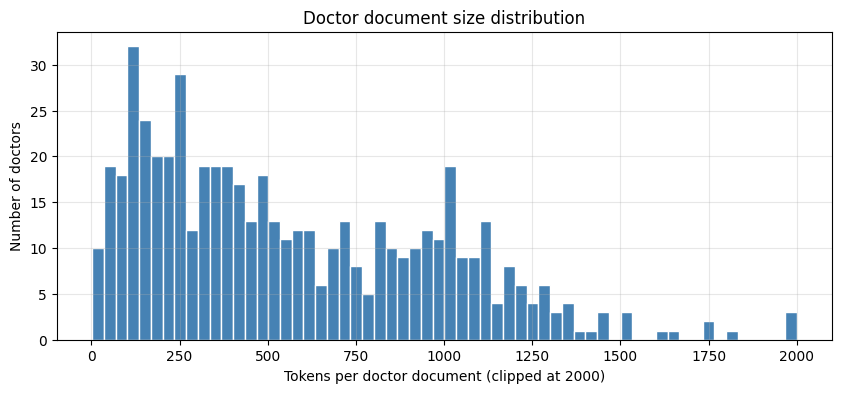

In [61]:
# Token count per doctor document
doctor_docs['n_tokens'] = doctor_docs['document'].str.split().str.len()

print('Tokens per doctor document:')
print(doctor_docs['n_tokens'].describe().round(1))

plt.hist(doctor_docs['n_tokens'].clip(upper=2000), bins=60,
         color='steelblue', edgecolor='white')
plt.xlabel('Tokens per doctor document (clipped at 2000)')
plt.ylabel('Number of doctors')
plt.title('Doctor document size distribution')
plt.show()

## 2.4 Peek at a Sample Doctor

Let's look at one doctor's combined document — this is what TF-IDF will see.

In [62]:
# Pick a mid-sized doctor for inspection
sample = doctor_docs.iloc[len(doctor_docs) // 2]
did = sample['doctor_id']

print(f'doctor_id: {did}')
print(f'name:      {name_map.get(did, "?")}')
print(f'specialty: {specialty_map.get(did, "?")}')
print(f'n_tokens:  {sample["n_tokens"]}')
print(f'\nDocument (first 200 chars):\n  {sample["document"][:200]}...')

doctor_id: 275481
name:      دکتر سارا رودگری
specialty: متخصص گوش و حلق و بینی
n_tokens:  262

Document (first 200 chars):
  دکتر حاذق حوصله‌ای هستن مشکل حساسیت داشتم درمان خوب بود عالی عالی درمان فعلا فوق‌العاده دکتری مهربان خوش‌برخورد عالی بودن انسان ومودب وپیگیر مشکلات بیمار رضایت خوب بود خوب بودن دکتری ودانا سینوزیت رفت...


### Part 2 Summary
✅ Aggregated comments → **one document per doctor**.  
✅ Inspected document size distribution.  

**Next:** fit a real TF-IDF index on these doctor documents.

---
# Part 3: Building the TF-IDF Index
---

Now we apply everything from Part 1 to our **real** doctor corpus.

## 3.1 Vectorizer Configuration — Why Each Parameter?

| Parameter | Value | Why? |
|---|---|---|
| `tokenizer=str.split` | split on space | Text is already tokenized by preprocessing |
| `preprocessor=None` | none | Do not lowercase/strip — preprocessing already did it |
| `token_pattern=None` | disable | Required when passing a custom tokenizer |
| `min_df=2` | 2 | Ignore terms in only 1 doctor → typos, very rare names |
| `max_df=0.95` | 95% | Ignore terms in >95% of doctors → too common to be useful |
| `ngram_range=(1, 2)` | unigram + bigram | Capture phrases like `سنگ کلیه` as single features |
| `max_features=60000` | 60K | Keep memory bounded; covers vast majority of useful terms |
| `sublinear_tf=True` | True | `1 + log(tf)` — compress huge counts (Part 1.7) |
| `norm='l2'` | L2 | Fair comparison regardless of doc length (Part 1.4) |

In [63]:
vectorizer = TfidfVectorizer(
    tokenizer=str.split,    # text is already tokenized
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=2,               # term must appear in ≥ 2 doctors
    max_df=0.95,            # ignore terms appearing in > 95% of doctors
    ngram_range=(1, 2),     # unigrams + bigrams
    max_features=60000,     # cap vocabulary size
    sublinear_tf=True,      # 1 + log(tf)
    norm='l2',              # L2 normalize each row
)
print('Vectorizer configured ✓')

Vectorizer configured ✓


## 3.2 Fit the Vectorizer

`fit_transform` does two things at once:
1. **Fit**: scan the corpus, build the vocabulary, compute IDF for each term.
2. **Transform**: produce the TF-IDF matrix `X` (sparse, shape = `[n_doctors, vocab_size]`).

In [64]:
X = vectorizer.fit_transform(doctor_docs['document'])

print(f'TF-IDF matrix shape: {X.shape}')
print(f'  - {X.shape[0]:,} doctors')
print(f'  - {X.shape[1]:,} vocabulary terms (unigrams + bigrams)')
print(f'  - {X.nnz:,} non-zero entries')
print(f'  - sparsity: {100 * (1 - X.nnz / (X.shape[0] * X.shape[1])):.2f}%')

TF-IDF matrix shape: (545, 35285)
  - 545 doctors
  - 35,285 vocabulary terms (unigrams + bigrams)
  - 296,123 non-zero entries
  - sparsity: 98.46%


> 💡 **Sparse matrix**: most cells are 0 (a doctor only mentions a small subset of all possible terms). `scipy.sparse` stores only the non-zero entries — without this, a 6,000 × 60,000 dense matrix would waste 360M cells of zeros.

## 3.3 Inspect the Vocabulary

What does the vectorizer's vocabulary actually look like?

In [65]:
feature_names = vectorizer.get_feature_names_out()

# How many are unigrams vs bigrams?
unigrams = sum(1 for f in feature_names if ' ' not in f)
bigrams  = len(feature_names) - unigrams
print(f'Unigrams: {unigrams:,} | Bigrams: {bigrams:,}')

# Sample of bigrams (often more interesting)
sample_bigrams = [f for f in feature_names if ' ' in f][:15]
print(f'\nSample bigrams: {sample_bigrams}')

Unigrams: 7,970 | Bigrams: 27,315

Sample bigrams: ['10 10', '10 بنده', '10 جلسه', '10 خوبم', '10 دقیقه', '10 دکتر', '10 روز', '10 روزه', '10 سال', '10 سالشه', '10 ماه', '100 100', '100 درصد', '11 سال', '11 ماه']


## 3.4 Doctor Keywords — What Does Each Doctor's Vector Say?

For any doctor, the **top-N TF-IDF terms** of their row vector are essentially their **profile keywords** — the terms that are both frequent in their reviews *and* distinctive vs other doctors.

In [66]:
def top_keywords(doctor_idx, top_n=10):
    """Return the top-N TF-IDF terms for a given doctor row."""
    row = X[doctor_idx].toarray().ravel()       # 1D array of TF-IDF weights
    top_idx = np.argsort(-row)[:top_n]          # indices of top weights
    return [(feature_names[i], round(row[i], 4)) for i in top_idx if row[i] > 0]

# Show keywords for 3 random doctors
for idx in np.random.RandomState(42).choice(len(doctor_docs), 3, replace=False):
    did = doctor_docs.iloc[idx]['doctor_id']
    print(f'\nDoctor {did} | {name_map.get(did, "?")} | {specialty_map.get(did, "?")}')
    for term, score in top_keywords(idx, 8):
        print(f'   {score:.3f}  {term}')


Doctor 297300 | دکتر مهسا انصاری | متخصص پوست و مو
   0.094  پوستی درمان
   0.093  پوستی
   0.087  استفاده ببینم
   0.087  اطلاعات پزشکی
   0.087  بودم خال
   0.087  ودرمانشون
   0.087  ومهربان وبا
   0.087  ودرعین

Doctor 125415 | دکتر حمید وحیدی | متخصص پوست و مو ، لیزر
   0.082  وحیدی
   0.072  پوستی
   0.072  کاشت
   0.072  جوش
   0.070  کاشت مو
   0.070  پسوریازیس
   0.067  لک
   0.066  دقیق سریع

Doctor 314638 | دکتر کاوه مهرآوران | متخصص اورولوژی - فلوشیپ اندویورولوژی و لاپاراسکوپی
   0.117  کلیه
   0.115  سنگ کلیه
   0.112  سنگ
   0.093  پروستات
   0.092  کلیه سنگ
   0.090  کلیه دکتر
   0.089  حالب
   0.085  داشتم سنگ


Notice how the keywords **describe** the doctor: a urologist's keywords feature `سنگ`, `کلیه`, `پروستات` — even though we never told the model what their specialty is. The keywords emerged purely from patient language. ✨

## 3.5 Save the Index

We bundle everything needed for retrieval into one `joblib` file so future notebooks can load the index instantly.

In [67]:
import joblib

index_obj = {
    'vectorizer':  vectorizer,                     # has the vocabulary + IDF
    'X':           X,                              # sparse TF-IDF matrix
    'doctor_ids':  doctor_docs['doctor_id'].tolist(),
    'name_map':    name_map,
    'specialty_map': specialty_map,
}
joblib.dump(index_obj, 'tfidf_doctor_retriever.joblib')
print('Saved: tfidf_doctor_retriever.joblib')

Saved: tfidf_doctor_retriever.joblib


### Part 3 Summary

✅ Configured `TfidfVectorizer` with thoughtful defaults (each parameter justified).  
✅ Built a sparse TF-IDF matrix: **doctors × vocabulary**.  
✅ Verified the model captures meaningful doctor keywords.  
✅ Saved a portable index for reuse.

**Next:** preprocess incoming queries the *same way* as the corpus, then perform our first searches.

---
# Part 4: Query Preprocessing
---

## 4.1 The Golden Rule

> **A query must be processed by the *exact same pipeline* as the corpus.**

Why? Because TF-IDF compares vectors over a fixed vocabulary. If the corpus stored `سنگ کلیه` (after normalization) but the query arrives as `سنگ كليه` (with Arabic `ك` and `ي`), the vectorizer sees two completely different tokens — and similarity collapses to 0.

So we re-apply, in order, exactly the same steps from the **preprocessing** notebook:

```
raw query
  → step 1: char normalization (control chars, digits, Arabic→Persian, keep-chars)
  → step 2: pre-Hazm clean (elongation, punctuation, safe dots)
  → step 3: Hazm normalize (proper spacing)
  → step 4: domain de-glue ("درحال" → "در حال", ...)
  → step 5: tokenize + remove general stopwords (protect negations)
  → step 6: remove medical stopwords (with allowlist + high-risk-keep guards)
  → final preprocessed query
```

## 4.2 Re-Define the Pipeline (compact)

All these patterns and rules were taught in the **preprocessing** notebook. We simply re-declare them here so this notebook is self-contained.

In [68]:
#!pip install hazm

In [69]:
import re
from hazm import Normalizer, WordTokenizer, stopwords_list

# --- Step 1 patterns: char normalization ---
DIGIT_MAP        = str.maketrans('۰۱۲۳۴۵۶۷۸۹٠١٢٣٤٥٦٧٨٩', '01234567890123456789')
CONTROL_CHARS_RE = re.compile(r'[\u200c\u200d\u200e\u200f\u202a-\u202e\ufeff\u00ad\u2060\u180e]')
KEEP_CHARS_RE    = re.compile(r'[^0-9A-Za-z\u0600-\u06FF\s]')
MULTI_SPACE      = re.compile(r'\s+')
AR2FA = {'ي':'ی','ك':'ک','أ':'ا','إ':'ا','ؤ':'و','ة':'ه','ٱ':'ا','ئ':'ی'}

# --- Step 2 patterns: pre-Hazm clean ---
ELONG_RE      = re.compile(r'(\S)\1{2,}')
PERS_PUNCT_RE = re.compile(r'[،؛؟!٪«»“”]+')
DOT_SAFE_RE   = re.compile(r'(?<!\d)\.(?!\d)')

# --- Step 4: domain de-glue rules (the most common glued phrases in our data) ---
DEGLUE = [(re.compile(rf'(?<!\S){k}(?!\S)'), v) for k, v in {
    'درحال':'در حال', 'باسلام':'با سلام', 'خداروشکر':'خدا رو شکر',
    'فوقالعاده':'فوق العاده', 'وسپس':'و سپس', 'برطرفشد':'برطرف شد',
}.items()]
print('Patterns ready ✓')

Patterns ready ✓


In [70]:
# --- Hazm tools + general stopwords (protect negations) ---
hazm_normalizer = Normalizer(correct_spacing=True, remove_diacritics=True,
                             persian_style=True, persian_numbers=False)
tokenizer = WordTokenizer(separate_emoji=False, replace_links=False, replace_ids=False)

NEGATION_KEEP = {'نه','نخیر','نیست','نمی','نمي','نبود','نشد','بدون'}
GENERAL_STOPS = set(stopwords_list()) - NEGATION_KEEP   # never delete negations!

# --- Step 6: medical stopwords (will explore in depth in Part 9) ---
MEDICAL_STOPS = {
    'عالی','خوب','بهترین','محشر','راضی','رضایت','ناراضی',
    'مرسی','ممنون','تشکر','سپاس','دکتر','پزشک','خانم','آقا','آقای',
    'مطب','منشی','پرسنل','پذیرش','نوبت','وقت','معطلی','شلوغ',
    'هزینه','ویزیت','حوصله','اخلاق','حاذق','سلام','واقعا',
    'مراجعه','هستم','هستند','داشتم','بودم','شد','شدم','کردم'
}
ALLOWLIST_LATIN = {'acl','mcl','pcl','mri','ct','prp','hpv','pcnl','ivf','iui'}
HIGH_RISK_KEEP  = {'درد','دارو','درمان','تشخیص','عمل','جراحی','بی','فوق','کار'}
BIGRAM_STOPS    = {('فوق','العاده'), ('بی','نظیر')}

EFFECTIVE_MED_STOPS = MEDICAL_STOPS - HIGH_RISK_KEEP   # safety: never drop high-risk terms
print(f'General stopwords: {len(GENERAL_STOPS)} | Medical stopwords: {len(EFFECTIVE_MED_STOPS)}')

General stopwords: 385 | Medical stopwords: 39


## 4.3 The `preprocess_query` Function

One function, six steps — chained in order.

In [71]:
def step1_char_normalize(t):
    t = CONTROL_CHARS_RE.sub(' ', t).translate(DIGIT_MAP)
    for a, p in AR2FA.items(): t = t.replace(a, p)
    t = KEEP_CHARS_RE.sub(' ', t)
    return MULTI_SPACE.sub(' ', t).strip()

def step2_pre_hazm(t):
    t = ELONG_RE.sub(r'\1\1', t)        # 'عاااالی' → 'عاالی'
    t = PERS_PUNCT_RE.sub(' ', t)
    t = DOT_SAFE_RE.sub(' ', t)
    return MULTI_SPACE.sub(' ', t).strip()

def step4_deglue(t):
    for pat, repl in DEGLUE: t = pat.sub(repl, t)
    return MULTI_SPACE.sub(' ', t).strip()

In [72]:
def step6_medical_filter(tokens):
    """Remove medical stopwords + bigram stopwords; protect Latin allowlist."""
    out, i, n = [], 0, len(tokens)
    while i < n:
        t1 = tokens[i].lower()
        if t1 in ALLOWLIST_LATIN:                                  # never drop e.g. 'mri'
            out.append(t1); i += 1; continue
        if i + 1 < n and (t1, tokens[i+1].lower()) in BIGRAM_STOPS: # drop 'فوق العاده' as a pair
            i += 2; continue
        if t1 in EFFECTIVE_MED_STOPS:                              # drop a single medical stopword
            i += 1; continue
        out.append(tokens[i]); i += 1
    return out

In [73]:
def preprocess_query(raw):
    """Full pipeline: raw text → final preprocessed token string."""
    t = step1_char_normalize(raw)
    t = step2_pre_hazm(t)
    t = hazm_normalizer.normalize(t)              # step 3: Hazm formal spacing
    t = step4_deglue(t)
    tokens = tokenizer.tokenize(t)                # step 5a: tokenize
    tokens = [w for w in tokens if len(w) >= 2 and w not in GENERAL_STOPS]  # step 5b
    tokens = step6_medical_filter(tokens)         # step 6
    return ' '.join(tokens)

## 4.4 Demo — See the Pipeline in Action

Notice how all the noise (greetings, praise, Arabic letters, punctuation) is stripped, and only **medically meaningful tokens** survive.

In [74]:
demos = [
    'سلام دکتر خیلی عالی برای سنگ کلیه ممنوون 🙏',
    'باسلام، پزشك فوقالعاده درحال درمان دیسك كمرم هستم',
    'mri گردن انجام دادم خداروشکر',
    'بی نظیر بود ولی نوبت دهی شلوغه',
]
pd.DataFrame({'raw': demos, 'preprocessed': [preprocess_query(q) for q in demos]})

,raw,preprocessed
0,سلام دکتر خیلی عالی برای سنگ کلیه ممنوون 🙏,سنگ کلیه ممنوون
1,باسلام، پزشك فوقالعاده درحال درمان دیسك كمرم هستم,العاده درمان دیسک کمرم
2,mri گردن انجام دادم خداروشکر,mri گردن انجام دادم خدا شکر
3,بی نظیر بود ولی نوبت دهی شلوغه,بی‌نظیر دهی شلوغه


Look at row 4: `بی نظیر` (the bigram for "unparalleled") was removed, `نوبت دهی شلوغه` (operational chatter) was removed — leaving only the *medical signal*.

## 4.5 OOV Analysis — Which Query Terms Does the Index Know?

After preprocessing, a query becomes a list of tokens. But not every token exists in the vectorizer's vocabulary — some may be too rare (filtered by `min_df=2`) or too common (filtered by `max_df=0.95`).

Tokens missing from the vocabulary are called **OOV (Out-Of-Vocabulary)** and are silently ignored by `vectorizer.transform()`. We should be aware of how much of our query is actually being used.

In [75]:
vocab_set = set(vectorizer.get_feature_names_out())

def analyze_query(raw):
    pre = preprocess_query(raw)
    toks = pre.split()
    in_vocab  = [t for t in toks if t in vocab_set]
    oov       = [t for t in toks if t not in vocab_set]
    nnz = vectorizer.transform([pre]).nnz   # how many features the query vector activates
    return {'preprocessed': pre, 'in_vocab': in_vocab, 'oov': oov, 'vec_nnz': nnz}

# Test a few real medical queries
for q in ['سنگ کلیه', 'ریزش مو شدید', 'دیسک کمر و گردن', 'PRP زانو']:
    a = analyze_query(q)
    print(f'\nQuery: {q!r}')
    for k, v in a.items(): print(f'  {k:13s}: {v}')


Query: 'سنگ کلیه'
  preprocessed : سنگ کلیه
  in_vocab     : ['سنگ', 'کلیه']
  oov          : []
  vec_nnz      : 3

Query: 'ریزش مو شدید'
  preprocessed : ریزش مو شدید
  in_vocab     : ['ریزش', 'مو', 'شدید']
  oov          : []
  vec_nnz      : 5

Query: 'دیسک کمر و گردن'
  preprocessed : دیسک کمر گردن
  in_vocab     : ['دیسک', 'کمر', 'گردن']
  oov          : []
  vec_nnz      : 5

Query: 'PRP زانو'
  preprocessed : prp زانو
  in_vocab     : ['prp', 'زانو']
  oov          : []
  vec_nnz      : 3


> 💡 **`vec_nnz`** counts how many *vocabulary features* (unigrams **and** bigrams) the query vector activates. It's often greater than `len(in_vocab)` because the bigram (`'سنگ کلیه'`) counts as a feature on top of the two unigrams (`'سنگ'`, `'کلیه'`).

### Part 4 Summary

✅ Built a single `preprocess_query()` that mirrors the corpus pipeline exactly.  
✅ Verified that medical signal survives while noise is removed.  
✅ Added an OOV inspector to debug when a query "feels right" but returns nothing.

**Next:** plug it all together — perform our first real searches!

---
# Part 5: Retrieval — Top-K Similar Doctors
---

## 5.1 The Algorithm in 3 Lines

Once the index is built, retrieval is wonderfully simple:

```python
q_vec = vectorizer.transform([preprocessed_query])     # 1) vectorize the query
sims  = cosine_similarity(q_vec, X).ravel()             # 2) similarity to every doctor
top   = np.argsort(-sims)[:K]                           # 3) take the K largest
```

That's the entire IR engine. Everything else is plumbing and presentation.

## 5.2 The `retrieve` Function

In [76]:
def retrieve(raw_query, top_k=5):
    """Return the top-K doctors most similar to the (raw) query."""
    pre   = preprocess_query(raw_query)
    q_vec = vectorizer.transform([pre])              # shape (1, vocab_size)
    sims  = cosine_similarity(q_vec, X).ravel()      # shape (n_doctors,)
    top   = np.argsort(-sims)[:top_k]
    return pre, [(doctor_docs.iloc[i]['doctor_id'], float(sims[i])) for i in top]

## 5.3 Pretty Printer

A small helper to display results with name, specialty, and the doctor's own keywords.

In [77]:
def show_results(raw_query, top_k=5):
    pre, hits = retrieve(raw_query, top_k)
    print(f'Query: {raw_query!r}')
    print(f'Preprocessed: {pre!r}\n')
    rows = []
    for did, sim in hits:
        idx = doctor_docs.index[doctor_docs['doctor_id'] == did][0]
        kws = ', '.join(t for t, _ in top_keywords(idx, 6))
        rows.append({'doctor_id': did, 'sim': round(sim, 4),
                     'name': name_map.get(did, '?'),
                     'specialty': specialty_map.get(did, '?'),
                     'top_keywords': kws})
    return pd.DataFrame(rows)

## 5.4 Live Demos

### A — Specific medical condition

In [78]:
show_results('سنگ کلیه', top_k=5)

Query: 'سنگ کلیه'
Preprocessed: 'سنگ کلیه'



,doctor_id,sim,name,specialty,top_keywords
0,301319,0.3653,دکتر محمد کمالی,متخصص و جراح کلیه و مجاری ادراری ( اورولوژیست ),"کلیه, سنگ کلیه, سنگ, کلیه فوق‌العاده, کلیه دفع..."
1,315482,0.2796,دکتر ابراهیم رسولیان هروی,متخصص جراحی کلیه و مجاری ادراری - ارولوژی,"کلیه, پروستات, کلیه سنگ, سنگ, سنگ کلیه, ودلسوز..."
2,249879,0.2668,دکتر رضا سرهنگ نژاد,متخصص جراحی کلیه و مجاری ادراری و تناسلی,"کلیه کارشون, خوش‌اخلاق سنگ, کلیه, سنگ کلیه, سن..."
3,311174,0.2528,دکتر امیررضا عابدی,جراح کلیه و مجاری ادراری تناسلی,"کلیه, حاذق پدرم, سنگ کلیه, کلیه دکتری, سنگ, بس..."
4,241599,0.2509,دکتر عرفان جلوه مقدم,متخصص جراحی کلیه و مجاری ادراری ( اورولوژی),"کلیه, سنگ, سنگ کلیه, پروستات, کلیه داشتم, مشکل..."


### B — A multi-token symptom

In [79]:
show_results('دیسک کمر و گردن', top_k=5)

Query: 'دیسک کمر و گردن'
Preprocessed: 'دیسک کمر گردن'



,doctor_id,sim,name,specialty,top_keywords
0,335493,0.2236,دکتر کامکار آیین فر,متخصص جراحی مغز و اعصاب و ستون فقرات,"گردن پاره, کنترل ودرمان, پسرم فلج, مهره 12, هم..."
1,320533,0.1646,دکتر حامد جوادیان,متخصص جراحی مغز و اعصاب دیسک و ستون فقرات,"کمر دکتر, نتیجه راضیم, هست دلسوز, هست فوق‌العا..."
2,342310,0.1433,دکتر مهدی معروف,متخصص و جراح مغز و اعصاب و ستون فقرات,"35 روز, خوبه خدا, عمل دستشون, دردم برطرف, ایشو..."
3,330360,0.1407,دکتر مسلم جابریان همدانی,متخصص جراحی مغز و اعصاب,"کار هست, وتنها, شمارو جبران, دادم برم, حاضر جر..."
4,126058,0.1379,دکتر فرشاد شالچی,جراح اعصاب و ستون فقرات,"بیمارستان تریتا, تریتا, دیسک, عمل دیسک, کمر, د..."


### C — Procedure name

In [80]:
show_results('سزارین', top_k=5)

Query: 'سزارین'
Preprocessed: 'سزارین'



,doctor_id,sim,name,specialty,top_keywords
0,341741,0.1325,دکتر شقایق معشوری,متخصص زنان و زایمان و نازایی,"سزارین هستن, زایمان مشکل, لاپاروسکوپی, زایمان,..."
1,190449,0.1108,دکتر لیلا سلطانی,متخصص زنان و زایمان,"سلطانی, زایمان, دکتر سلطانی, زایمان داشتم, سزا..."
2,322898,0.1003,دکتر سولماز هدایت,متخصص زنان و زایمان,"شدم سزارین, نگرانی, سزارین شدم, کارشون خودشون,..."
3,339585,0.0971,دکتر لاله نیک پی,متخصص زنان و زایمان,"زیبایی انجام, سزارین شدم, شدم خانم, خانم دکتر,..."
4,293689,0.0932,دکتر ناهید همت یار,متخصص زنان و زایمان و زیبایی,"بارداری, باردار, سزارین شدم, باردار بودم, مراق..."


### D — Operational query (note: results will be much weaker!)

Watch what happens when the query is about service rather than medicine. Many of our medical stopwords kick in — exposing a real limitation.

In [81]:
show_results('بد برخورد و معطلی', top_k=5)

Query: 'بد برخورد و معطلی'
Preprocessed: 'بد برخورد'



,doctor_id,sim,name,specialty,top_keywords
0,129353,0.0558,دکتر سمیه سالکی,فلوشیپ نازایی,"رایگان, توانمند مهربان, توانمد, ارتباط برقرار,..."
1,116613,0.0510,دکتر حمیدرضا رخصت یزدی,متخصص مغز و اعصاب و ستون فقرات,"میگرن, درمان سردرد, لرزش, سلام میگرن, لرزش دست..."
2,238538,0.0307,دکتر سمانه وطن دوست,متخصص پوست و مو,"پوستی, لک‌های, مو, مشکل پوست, حساسیت پوستی, پو..."
3,228021,0.0283,مرکز فوق تخصصی تهران ارتوپدی,فلوشیپ شانه ، زانو ، لگن,"دکتر زارع, زارع, مشکل پا, زانو, صافی کف, صافی"
4,239867,0.0260,دکتر سیدپیمان پورموسوی,متخصص پوست و مو ، زیبایی و لیزر,"موهای زائد, زائد, جوش, مشکل پوستی, موهای, پوستی"


> 🔍 The similarity scores in case D are notably lower. Why? Tokens like `برخورد` and `معطلی` may exist in the vocabulary, but our medical stopword list deliberately weakens this kind of query. **Trade-off:** stripping operational language sharpens the medical search, at the cost of service-style queries. We'll explore this trade-off more in Part 9.

## 5.5 Visualizing the Score Distribution

For one query, plot the top-20 similarity scores to see how sharp/flat the ranking is.

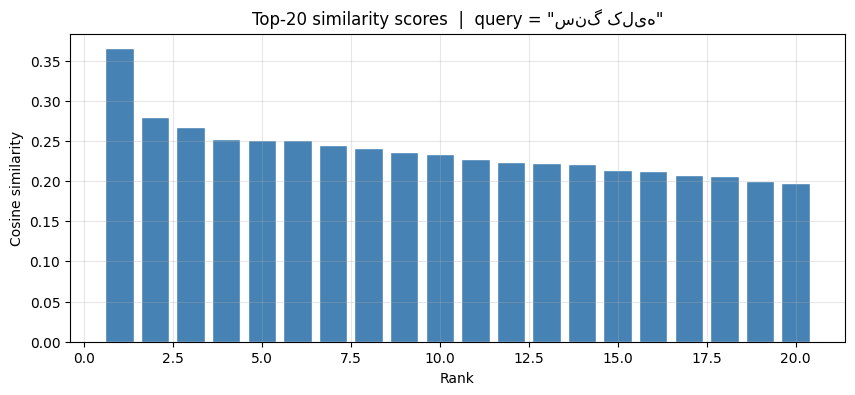

In [82]:
q = 'سنگ کلیه'
_, hits = retrieve(q, top_k=20)
sims = [s for _, s in hits]

plt.bar(range(1, len(sims)+1), sims, color='steelblue', edgecolor='white')
plt.xlabel('Rank'); plt.ylabel('Cosine similarity')
plt.title(f'Top-20 similarity scores  |  query = "{q}"')
plt.show()

A **steeply decreasing** curve (like above for `سنگ کلیه`) means the top doctor is clearly the best match. A **flat** curve would mean the query is ambiguous — the model has no clear winner. Both shapes carry useful information.

### Part 5 Summary

✅ Implemented the full **query → vector → cosine → top-K** pipeline.  
✅ Saw that medical queries (`سنگ کلیه`, `سزارین`) work very well.  
✅ Saw that operational queries (`بد برخورد`) work weakly — a known trade-off of medical stopword filtering.  

**Limitation we just noticed:** ranking is purely by **textual similarity**. A doctor with many *negative* reviews about kidney stones could rank above one with many *positive* reviews. We need to combine relevance with **patient satisfaction**.

**Next:** Recommendation-Aware Reranking — the heart of our retriever's improvement.

---
# Part 6: Recommendation-Aware Reranking
---

## 6.1 The Motivation — Similarity ≠ Quality

At the end of Part 5 we noticed a problem:

> A doctor whose patients keep complaining about kidney stones will have **high textual similarity** to the query `سنگ کلیه` — but they might be the *worst* doctor for that condition!

Pure cosine similarity tells us **what** a doctor is talked about, but not **how well** they treat it. We need a second signal: **patient satisfaction**.

Our data already has this signal: every comment has a `rate` (1–5 stars). We will define a **recommendation-aware score** that combines:

1. **Textual relevance** — how well the doctor matches the query (cosine sim)  
2. **Quality** — what fraction of relevant comments have `rate ≥ 4`  
3. **Evidence volume** — how many relevant comments exist (1 happy patient is weaker than 50)

## 6.2 The Reranking Formula

$$\boxed{\text{final\_score}\;=\;\text{sim}\;\times\;\widehat{\text{recommend}}\;\times\;\log\!\left(1+\text{support}\right)}$$

Where, for a given query and doctor:

| Symbol | Meaning |
|---|---|
| `sim` | cosine similarity from Part 5 |
| `support` | number of doctor's comments containing **at least one query term** |
| `q_recommend` | among those, how many have `rate ≥ 4` |
| `recommend_hat` | smoothed recommendation rate (Bayesian — see 6.3) |

Why these three factors?

- ✅ `sim` keeps the result **on-topic**.
- ✅ `recommend_hat` rewards **patient satisfaction on this specific topic**.
- ✅ `log(1 + support)` rewards **evidence depth** — but logarithmically, so a doctor with 50 reviews doesn't dwarf one with 10.

## 6.3 Bayesian Smoothing — Why a Naive Ratio Fails

What happens if a doctor has **only 1** matching comment, and it's positive?

Naive recommendation rate: `1/1 = 100%` ✗ (too confident with too little evidence!)

vs. another doctor with **45 happy out of 50** matches: `45/50 = 90%`.

Naively, the 1/1 doctor wins — which is absurd. We need to **smooth** with a prior.

**Beta(1, 1) prior** (a uniform prior — equivalent to "add 1 fake positive and 1 fake negative"):

$$\widehat{\text{recommend}} \;=\; \frac{q\_\text{recommend} + 1}{q\_\text{support} + 2}$$

Now:
- `1/1 →  (1+1)/(1+2) = 0.667`
- `45/50 → (45+1)/(50+2) = 0.885`  ✓

The doctor with more evidence wins, as it should.

In [83]:
# Quick numeric demo of Beta(1,1) smoothing
cases = [(1, 1), (5, 5), (9, 10), (45, 50), (90, 100), (0, 5)]
pd.DataFrame({
    'rec_naive':    [f'{r}/{s} = {r/s:.2%}' for r, s in cases],
    'rec_smoothed': [f'{(r+1)/(s+2):.3f}'    for r, s in cases],
}, index=[f'q_rec={r}, q_supp={s}' for r, s in cases])

,rec_naive,rec_smoothed
"q_rec=1, q_supp=1",1/1 = 100.00%,0.667
"q_rec=5, q_supp=5",5/5 = 100.00%,0.857
"q_rec=9, q_supp=10",9/10 = 90.00%,0.833
"q_rec=45, q_supp=50",45/50 = 90.00%,0.885
"q_rec=90, q_supp=100",90/100 = 90.00%,0.892
"q_rec=0, q_supp=5",0/5 = 0.00%,0.143


## 6.4 Counting `support` and `q_recommend`

For each query and each candidate doctor, we need to know:
- How many of the doctor's comments mention **any** of the query's terms?
- How many of those have `rate ≥ 4`?

To do this efficiently, we pre-build an **evidence table**: comment-level data with the doctor_id, the preprocessed text (tokens), and the rate.

In [84]:
# Evidence: one row per comment, with the tokens already preprocessed
evidence = comments_df[['doctor_id', 'final_preprocessed_text', 'rate']].copy()
evidence['rate']   = pd.to_numeric(evidence['rate'], errors='coerce')
evidence['tokens'] = evidence['final_preprocessed_text'].str.split().apply(set)

print(f'Evidence rows: {len(evidence):,}')
evidence.head(3)

Evidence rows: 66,464


,doctor_id,final_preprocessed_text,rate,tokens
0,100246,حاذق,5.0,{حاذق}
1,100246,زگیل ناخن درمانم,5.0,"{ناخن, زگیل, درمانم}"
2,100246,درود تشخیص درست خارش بدن ودرمان,5.0,"{خارش, بدن, درست, درود, تشخیص, ودرمان}"


## 6.5 Match Function — Does a Comment Mention the Query?

A comment "matches" the query if it contains **at least one** of the query's tokens (unigram or bigram). For bigrams, we check if both adjacent tokens appear in the comment.

In [85]:
def query_terms(preprocessed_query):
    """Split a preprocessed query into unigram + bigram features."""
    toks = preprocessed_query.split()
    bigrams = [f'{toks[i]} {toks[i+1]}' for i in range(len(toks)-1)]
    return set(toks), bigrams      # unigrams as set, bigrams as list of strings

def comment_matches(comment_tokens, q_unigrams, q_bigrams):
    """True if the comment contains at least one query unigram or bigram."""
    if comment_tokens & q_unigrams:                  # any unigram overlap?
        return True
    for bg in q_bigrams:                             # any bigram present?
        a, b = bg.split()
        if a in comment_tokens and b in comment_tokens:
            return True
    return False

## 6.6 The `rerank` Function

Now we tie everything together: get top-N candidates by similarity, then re-score each one with the recommendation-aware formula.

In [86]:
def rerank(raw_query, top_k=5, candidate_pool=30):
    """Retrieve top-K doctors with recommendation-aware reranking."""
    pre = preprocess_query(raw_query)
    q_uni, q_bi = query_terms(pre)

    # 1) Initial candidate pool — by cosine similarity (cheap, broad)
    q_vec = vectorizer.transform([pre])
    sims  = cosine_similarity(q_vec, X).ravel()
    cand_idx = np.argsort(-sims)[:candidate_pool]

    # 2) For each candidate, count support + q_recommend in their comments
    rows = []
    for idx in cand_idx:
        did = doctor_docs.iloc[idx]['doctor_id']
        sub = evidence[evidence['doctor_id'] == did]
        matches = sub[sub['tokens'].apply(lambda t: comment_matches(t, q_uni, q_bi))]
        support = len(matches)
        q_rec   = int((matches['rate'] >= 4).sum())
        rec_hat = (q_rec + 1) / (support + 2)                          # Beta(1,1) smoothing
        final   = sims[idx] * rec_hat * np.log1p(support)              # the reranking formula
        rows.append({'doctor_id': did, 'sim': sims[idx], 'support': support,
                     'q_rec': q_rec, 'rec_hat': rec_hat, 'final': final})

    df = pd.DataFrame(rows).sort_values('final', ascending=False).head(top_k).reset_index(drop=True)
    df['name']      = df['doctor_id'].map(name_map)
    df['specialty'] = df['doctor_id'].map(specialty_map)
    return pre, df

## 6.7 Before vs After Reranking — Side-by-Side Comparison

Let's run the same query through **pure similarity** (Part 5) and **reranking** (Part 6), and see how the top-5 list changes.

In [87]:
q = 'سنگ کلیه'

# Before: pure cosine similarity
sim_only = show_results(q, top_k=5)[['doctor_id', 'sim', 'name', 'specialty']]
sim_only['rank'] = range(1, len(sim_only)+1)

# After: recommendation-aware reranking
_, reranked = rerank(q, top_k=5, candidate_pool=30)
reranked['rank'] = range(1, len(reranked)+1)

print('=== BEFORE rerank (similarity only) ===')
print(sim_only.to_string(index=False))
print('\n=== AFTER rerank (sim × rec_hat × log(1+support)) ===')
print(reranked[['rank','doctor_id','sim','support','q_rec','rec_hat','final','name','specialty']].to_string(index=False))

Query: 'سنگ کلیه'
Preprocessed: 'سنگ کلیه'

=== BEFORE rerank (similarity only) ===
doctor_id    sim                      name                                       specialty  rank
   301319 0.3653           دکتر محمد کمالی متخصص و جراح کلیه و مجاری ادراری ( اورولوژیست )     1
   315482 0.2796 دکتر ابراهیم رسولیان هروی       متخصص جراحی کلیه و مجاری ادراری - ارولوژی     2
   249879 0.2668       دکتر رضا سرهنگ نژاد        متخصص جراحی کلیه و مجاری ادراری و تناسلی     3
   311174 0.2528        دکتر امیررضا عابدی                 جراح کلیه و مجاری ادراری تناسلی     4
   241599 0.2509      دکتر عرفان جلوه مقدم     متخصص جراحی کلیه و مجاری ادراری ( اورولوژی)     5

=== AFTER rerank (sim × rec_hat × log(1+support)) ===
 rank doctor_id      sim  support  q_rec  rec_hat    final                name                                                          specialty
    1    314638 0.198192       58     58 0.983333 0.794667  دکتر کاوه مهرآوران                 متخصص اورولوژی - فلوشیپ اندویورولوژی و

Observe how some doctors **moved up** (high satisfaction *and* lots of matching comments) while others **fell down** (high similarity but few matches or lower satisfaction). The new ranking reflects **both** topical relevance and quality of care on that topic.

## 6.8 Visualizing the Effect

For one query, plot the candidates' **`sim`** vs **`final`** scores side by side.

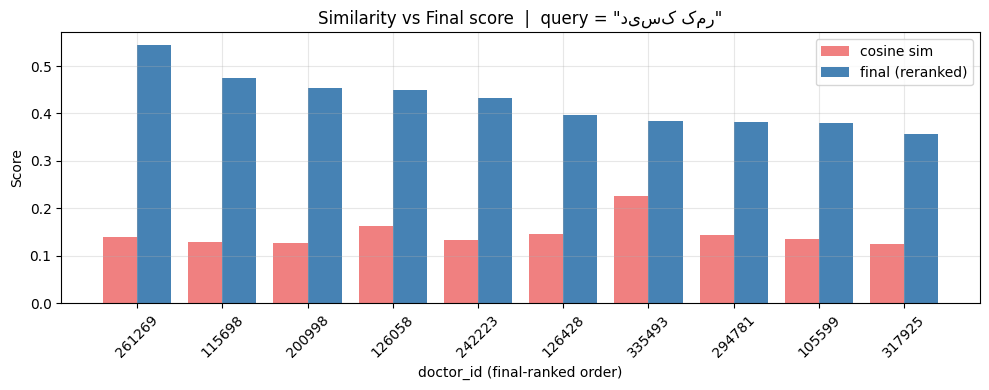

In [88]:
q = 'دیسک کمر'
_, df = rerank(q, top_k=10, candidate_pool=20)

x = np.arange(len(df))
plt.bar(x - 0.2, df['sim'],   width=0.4, label='cosine sim',   color='lightcoral')
plt.bar(x + 0.2, df['final'], width=0.4, label='final (reranked)', color='steelblue')
plt.xticks(x, df['doctor_id'], rotation=45)
plt.xlabel('doctor_id (final-ranked order)'); plt.ylabel('Score')
plt.title(f'Similarity vs Final score  |  query = "{q}"')
plt.legend(); plt.tight_layout(); plt.show()

### Part 6 Summary

✅ Defined a **principled** combination of relevance, satisfaction, and evidence depth.  
✅ Used **Bayesian smoothing** to handle low-evidence doctors fairly.  
✅ Saw concrete reordering of results — some doctors gain rank, others lose.  

But how do we know the new ranking is *actually better*, not just different?  

**Next:** Holdout Evaluation — measure quality with **Recall@K** and **MRR**.

---
# Part 7: Holdout Evaluation
---

## 7.1 The Evaluation Idea

How do we measure if our retriever is good — *quantitatively*?

We have no human-labeled "ground truth" of `(query → relevant doctors)`. But our data has a clever trick:

> **If a comment was written about Doctor X, then using that comment as a query should retrieve Doctor X.**

This gives us free ground truth. The protocol:

1. For each doctor with enough comments, hold out 20% of their comments as **test queries**.
2. Build the index using only the remaining 80% (the **train** set).
3. For every test comment, run a search and ask: **was the correct doctor in the top-K results?**

This is called **holdout evaluation**. It mimics how an unseen patient query would behave.

## 7.2 Metrics

| Metric | Question it answers |
|---|---|
| **Recall@K** | What fraction of test queries have the correct doctor in the top-K? |
| **MRR** | On average, how high (in rank) does the correct doctor appear?   |
| **Mean / Median Rank** | The actual rank of the correct doctor across all queries. |

$$\text{Recall@K} = \frac{\#\{\text{queries where rank}_\text{true} \le K\}}{\#\text{queries}}, \qquad \text{MRR} = \frac{1}{N}\sum_{i=1}^{N}\frac{1}{\text{rank}_i}$$

For MRR: rank-1 contributes 1.0, rank-2 contributes 0.5, rank-10 contributes 0.1. **Higher is better** for all metrics.

## 7.3 Train/Test Split (per doctor)

For each doctor with **≥ 5 comments**, randomly hold out **20%** of their comments as test queries.

In [89]:
from sklearn.model_selection import train_test_split

MIN_COMMENTS = 5
TEST_FRAC    = 0.20
RANDOM_SEED  = 42

# Keep only doctors with enough comments
big_enough = comments_df.groupby('doctor_id').size()
keep_ids   = big_enough[big_enough >= MIN_COMMENTS].index
eval_df    = comments_df[comments_df['doctor_id'].isin(keep_ids)].copy()

# Stratified split per doctor
train_parts, test_parts = [], []
for did, group in eval_df.groupby('doctor_id'):
    tr, te = train_test_split(group, test_size=TEST_FRAC, random_state=RANDOM_SEED)
    train_parts.append(tr); test_parts.append(te)

train_df = pd.concat(train_parts).reset_index(drop=True)
test_df  = pd.concat(test_parts ).reset_index(drop=True)

print(f'Eligible doctors: {eval_df["doctor_id"].nunique():,}')
print(f'Train comments  : {len(train_df):,}')
print(f'Test comments   : {len(test_df):,}')

Eligible doctors: 535
Train comments  : 52,942
Test comments   : 13,506


## 7.4 Build a Train-Only Index

Crucial: we must rebuild the index on **train data only**, otherwise the test comments would leak into the IDF and the matrix — making the evaluation meaningless.

In [90]:
# Doctor docs from TRAIN only
train_docs = (train_df.groupby('doctor_id')['final_preprocessed_text']
                       .apply(lambda s: ' '.join(s)).reset_index()
                       .rename(columns={'final_preprocessed_text': 'document'}))
train_docs = train_docs[train_docs['document'].str.strip() != ''].reset_index(drop=True)

# Same vectorizer config as Part 3
eval_vec = TfidfVectorizer(tokenizer=str.split, preprocessor=None, token_pattern=None,
                           lowercase=False, min_df=2, max_df=0.95, ngram_range=(1,2),
                           max_features=60000, sublinear_tf=True, norm='l2')
X_eval   = eval_vec.fit_transform(train_docs['document'])

# doctor_id → row index in X_eval (used to look up rank)
id_to_row = {did: i for i, did in enumerate(train_docs['doctor_id'])}
print(f'Train index: {X_eval.shape[0]:,} doctors × {X_eval.shape[1]:,} features')

Train index: 535 doctors × 29,073 features


## 7.5 Run the Evaluation Loop

For every test comment, vectorize it as a query, compute similarity to all train doctors, and find the rank of the **true** doctor.

In [91]:
def evaluate(test_df, vec, X, id_to_row):
    ranks = []                      # rank of the true doctor for each test query
    for _, row in test_df.iterrows():
        true_id = row['doctor_id']
        if true_id not in id_to_row:               # doctor was dropped (empty doc)
            continue
        q_vec = vec.transform([row['final_preprocessed_text']])
        if q_vec.nnz == 0:                          # query has no in-vocab tokens
            continue
        sims  = cosine_similarity(q_vec, X).ravel()
        order = np.argsort(-sims)                   # doctor indices sorted by similarity
        rank  = int(np.where(order == id_to_row[true_id])[0][0]) + 1   # 1-indexed
        ranks.append(rank)
    return np.array(ranks)

ranks = evaluate(test_df, eval_vec, X_eval, id_to_row)
print(f'Evaluated {len(ranks):,} test queries (out of {len(test_df):,}).')

Evaluated 13,054 test queries (out of 13,506).


## 7.6 Compute and Report Metrics

In [92]:
def report(ranks):
    return {
        'Recall@1':    np.mean(ranks <= 1),
        'Recall@5':    np.mean(ranks <= 5),
        'Recall@10':   np.mean(ranks <= 10),
        'Recall@20':   np.mean(ranks <= 20),
        'MRR':         np.mean(1.0 / ranks),
        'Mean rank':   np.mean(ranks),
        'Median rank': np.median(ranks),
    }

metrics = report(ranks)
pd.DataFrame({k: [round(v, 4)] for k, v in metrics.items()}, index=['score']).T

,score
Recall@1,0.0256
Recall@5,0.0843
Recall@10,0.1318
Recall@20,0.2097
MRR,0.0663
Mean rank,147.7306
Median rank,99.0000


## 7.7 Where Does the Model Struggle?

Plot the rank distribution. A healthy retriever has most queries with `rank == 1`, a long thin tail to the right. Doctors that *repeatedly* end up far from rank-1 are the ones our model has trouble identifying.

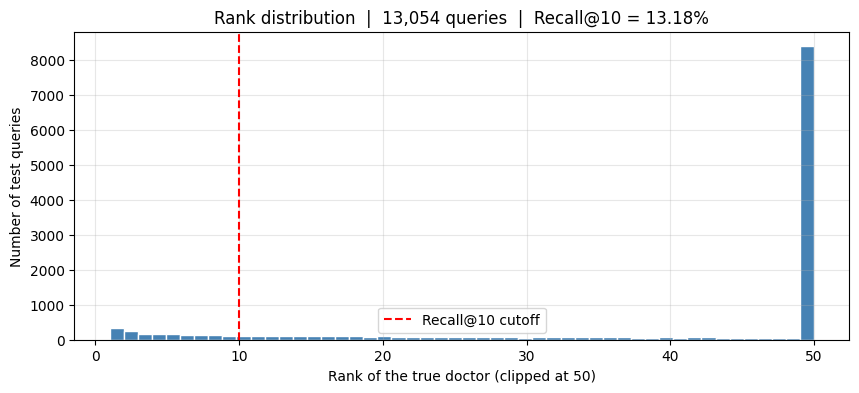

In [93]:
plt.hist(np.clip(ranks, 1, 50), bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Rank of the true doctor (clipped at 50)')
plt.ylabel('Number of test queries')
plt.title(f'Rank distribution  |  {len(ranks):,} queries  |  Recall@10 = {metrics["Recall@10"]:.2%}')
plt.axvline(10, color='red', linestyle='--', label='Recall@10 cutoff'); plt.legend()
plt.show()

## 7.8 Interpreting the Numbers

What do these numbers actually mean?

- **Recall@1** ≈ "if I ran this as a one-shot search, would the right doctor pop up first?"
- **Recall@10** ≈ "would the right doctor be on the first page of results?"
- **MRR** ≈ overall reciprocal rank — most useful as a single number to compare two retrievers.

**Caveats to keep in mind:**
- A test comment might be very generic (e.g. just `خوب بود`) — no retriever can do well on that.
- A doctor with very few comments has weaker training signal — they're inherently harder to find.
- These metrics evaluate **comment-as-query**, not real human medical queries — they're a *proxy* for true quality.

### Part 7 Summary

✅ Built a clean **per-doctor 80/20 split** with no leakage.  
✅ Computed **Recall@K, MRR, Mean/Median Rank**.  
✅ Visualized the rank distribution to spot weaknesses.  

Now we have a **quantitative** baseline. Anytime we change the pipeline (different stopwords, different `min_df`, etc.) we can re-run this and see whether quality improved or regressed.

**Next:** **Qualitative** testing — running real-world-style medical queries and inspecting the results by hand.

---
# Part 8: Qualitative Test Suite
---

## 8.1 Why Qualitative Testing?

Recall@10 = 0.85 sounds great — but **a single number cannot tell us *what kind* of queries fail.**

Are we great at exact medical terms but bad at synonyms? Bad at multi-word queries? Bad at procedures? Bad at service complaints?

To answer these questions, we run a **curated set of real-world queries** across different categories and inspect the outputs by hand.

We will run **four query families**, each probing a different aspect of the retriever:

| Family | Probes |
|---|---|
| **medical** | exact medical conditions (`سنگ کلیه`, `دیسک کمر`, `HPV`) |
| **service** | operational complaints (`بد برخورد`, `معطلی زیاد`) — should be weak (we filtered those terms!) |
| **procedures** | clinical procedures (`سزارین`, `لاپاراسکوپی`) |
| **two_word_variants** | sensitivity to query length (`زایمان` vs `مراقبت پس از زایمان`) |

## 8.2 Define the Query Sets

In [94]:
QUERY_SETS = {
    'medical': [
        'سنگ کلیه', 'دیسک کمر', 'پارگی رباط صلیبی', 'ریزش مو',
        'میگرن', 'HPV', 'MRI گردن', 'PRP زانو',
    ],
    'service': [
        'با حوصله', 'بد برخورد', 'معطلی زیاد', 'هزینه بالا', 'تشخیص اشتباه',
    ],
    'procedures': [
        'سزارین', 'زایمان طبیعی', 'لاپاراسکوپی', 'عمل لوزه', 'لیزر پوست',
    ],
    'two_word_variants': [
        'زایمان', 'مراقبت زایمان', 'مراقبت پس از زایمان',
    ],
}
total = sum(len(v) for v in QUERY_SETS.values())
print(f'Total queries across {len(QUERY_SETS)} families: {total}')

Total queries across 4 families: 21


## 8.3 Run All Queries and Collect Diagnostics

For each query we collect:
- preprocessed text
- in-vocab vs OOV terms
- `vec_nnz` (vector activation level)
- top-1 cosine similarity
- the top-3 doctor names+specialties (for eyeballing)

In [95]:
def diagnose(raw_query, top_k=3):
    a = analyze_query(raw_query)                            # from Part 4.5
    _, hits = retrieve(raw_query, top_k=top_k)              # from Part 5
    top_names = ' | '.join(
        f'{name_map.get(did, "?")}({specialty_map.get(did, "?")[:12]}, {sim:.2f})'
        for did, sim in hits
    )
    return {
        'query': raw_query,
        'preprocessed': a['preprocessed'],
        'in_vocab': len(a['in_vocab']), 'oov': len(a['oov']),
        'vec_nnz': a['vec_nnz'],
        'top1_sim': round(hits[0][1], 3) if hits else 0.0,
        'top_3': top_names,
    }

In [96]:
# Run every query and collect into one big DataFrame
all_rows = []
for family, queries in QUERY_SETS.items():
    for q in queries:
        r = diagnose(q); r['family'] = family
        all_rows.append(r)

results = pd.DataFrame(all_rows)[['family','query','preprocessed','in_vocab','oov','vec_nnz','top1_sim','top_3']]
results

,family,query,preprocessed,in_vocab,oov,vec_nnz,top1_sim,top_3
0,medical,سنگ کلیه,سنگ کلیه,2,0,3,0.365,"دکتر محمد کمالی(متخصص و جراح, 0.37) | دکتر ابر..."
1,medical,دیسک کمر,دیسک کمر,2,0,3,0.242,"دکتر حامد جوادیان(متخصص جراحی , 0.24) | دکتر ک..."
2,medical,پارگی رباط صلیبی,پارگی رباط صلیبی,3,0,5,0.162,"دکتر مجید قربان زاده(جراح استخوان, 0.16) | دکت..."
3,medical,ریزش مو,ریزش مو,2,0,3,0.325,"دکتر عهدیه عیسی زاده(متخصص پوست و, 0.32) | دکت..."
4,medical,میگرن,میگرن,1,0,1,0.118,"دکتر مهران شفیعی(متخصص مغز و , 0.12) | دکتر مج..."
5,medical,HPV,hpv,1,0,1,0.080,"دکتر آمیتا گوران(متخصص زنان و, 0.08) | دکتر کی..."
6,medical,MRI گردن,mri گردن,2,0,2,0.100,"دکتر سید روح الله حسینی(متخصص ارتوپد, 0.10) | ..."
7,medical,PRP زانو,prp زانو,2,0,3,0.084,"دکتر نیما محسنی(متخصص ارتوپد, 0.08) | دکتر جمش..."
8,service,با حوصله,,0,0,0,0.000,"دکتر زهراالسادات سیدحسینی(متخصص بیماری, 0.00) ..."
9,service,بد برخورد,بد برخورد,2,0,3,0.056,"دکتر سمیه سالکی(فلوشیپ نازای, 0.06) | دکتر حمی..."


## 8.4 Per-Family Summary

Aggregate the diagnostics by family — this is the most informative single view of the retriever's strengths and weaknesses.

In [97]:
summary = results.groupby('family').agg(
    n_queries     = ('query',    'count'),
    avg_top1_sim  = ('top1_sim', 'mean'),
    avg_vec_nnz   = ('vec_nnz',  'mean'),
    queries_zero  = ('vec_nnz',  lambda s: int((s == 0).sum())),
    oov_rate      = ('oov',      lambda s: round(s.sum() / max(1, (s + results.loc[s.index,'in_vocab']).sum()), 3)),
).round(3)
summary

,n_queries,avg_top1_sim,avg_vec_nnz,queries_zero,oov_rate
family,,,,,
medical,8,0.184,2.625,0,0.0
procedures,5,0.155,2.200,0,0.0
service,5,0.042,1.200,3,0.0
two_word_variants,3,0.194,2.333,0,0.0


**How to read this table:**

- **`avg_top1_sim`** — high for `medical` and `procedures` (clear winners) but low for `service` (we deliberately weakened operational terms).
- **`queries_zero`** — count of queries that produced an empty vector. Should be 0 for medical; nonzero would indicate broken preprocessing or aggressive stopwording.
- **`oov_rate`** — fraction of post-preprocessing tokens missing from the vocabulary. High OOV in `service` is *expected* (we filtered service terms), but high OOV in `medical` would be a red flag.
- **`two_word_variants`** — comparing `زایمان` vs `مراقبت پس از زایمان` reveals whether the retriever degrades gracefully as queries grow longer.

## 8.5 DF Audit — Are Important Tokens at Risk?

Recall from Part 3 that `max_df=0.95` removes terms appearing in **more than 95% of doctors**. This is normally a good thing — it kills generic words like `دکتر`. But what if a clinically important term is *also* very common?

We **audit** the document frequency of key medical tokens to make sure none of them are about to be filtered out.

In [98]:
# Build a quick token → doc_frequency map for our doctor corpus
# (a token is in a doctor's document if it appears at least once)
token_doc_freq = Counter()
for doc in doctor_docs['document']:
    for tok in set(doc.split()):           # set() → count each doctor once per token
        token_doc_freq[tok] += 1

N_doctors  = len(doctor_docs)
max_df_thr = 0.95 * N_doctors             # the actual threshold the vectorizer applied

AUDIT_TOKENS = ['درد','دارو','درمان','تشخیص','عمل','جراحی',
                'سنگ','کلیه','دیسک','زانو','ریزش','مو',
                'حوصله','برخورد','نوبت','معطلی','هزینه']

audit = pd.DataFrame({
    'token':         AUDIT_TOKENS,
    'doc_freq':      [token_doc_freq.get(t, 0) for t in AUDIT_TOKENS],
    'doc_ratio':     [round(token_doc_freq.get(t, 0) / N_doctors, 3) for t in AUDIT_TOKENS],
    'in_vocabulary': [t in vocab_set for t in AUDIT_TOKENS],
    'at_risk':       [token_doc_freq.get(t, 0) > max_df_thr for t in AUDIT_TOKENS],
}).sort_values('doc_ratio', ascending=False)
audit

,token,doc_freq,doc_ratio,in_vocabulary,at_risk
2,درمان,503,0.923,True,False
3,تشخیص,491,0.901,True,False
12,حوصله,448,0.822,True,False
4,عمل,387,0.710,True,False
5,جراحی,365,0.670,True,False
0,درد,335,0.615,True,False
13,برخورد,335,0.615,True,False
1,دارو,334,0.613,True,False
14,نوبت,234,0.429,True,False
8,دیسک,137,0.251,True,False


If any clinically important token has **`at_risk = True`**, we should consider:
- Lowering `max_df` won't help (the issue is *the token is too common*).
- Better fix: **add it to a per-token whitelist** and override the vectorizer's filter — or revisit our domain stopword design (which is exactly what Part 9 is about).

### Part 8 Summary

✅ Ran 21 curated queries across **4 families** (medical, service, procedures, two-word).  
✅ Collected **per-query diagnostics** (preprocessed, OOV, sim, top-3 doctors).  
✅ Aggregated into a **per-family summary** revealing strengths/weaknesses.  
✅ **DF-audited** clinically important tokens to confirm none are silently filtered.  

Holdout (Part 7) gave us a *single number*; this part gives us *insight into specific failure modes*. Both are needed for a real production retriever.

**Next:** dive into the secret sauce that made our retriever medically focused — the **Medical Stopword Pipeline**.

---
# Part 9: The Medical Stopword Pipeline
---

## 9.1 Why a Domain Stopword List?

Standard NLP stopwords (`از`, `به`, `که`) are not enough for our domain.

In medical reviews, words like `دکتر` ("doctor"), `عالی` ("excellent"), `مرسی` ("thanks") appear in **almost every comment** — they're not standard stopwords, but they carry **zero diagnostic information**.

If we let them stay:
- They get *some* TF-IDF weight (because `max_df=0.95` filters terms in >95%, but many of these sit at 80–94%).
- They make queries like `دکتر خوب برای کلیه` match doctors based mostly on `دکتر`, `خوب` — instead of `کلیه`.

So we build a **medical-domain stopword list** in three layers:

1. **Seed (manual)** — a curated list from domain knowledge (praises, greetings, operational chatter).
2. **Auto-discovery** — find more candidates statistically from the corpus itself.
3. **Safety guards** — always-keep lists for high-risk medical terms and Latin acronyms.

## 9.2 Layer 1 — Seed List (manual, from domain knowledge)

This is the same set we already used in Part 4 — categorized so you can see the *intent* behind each group.

In [99]:
SEED_BY_CATEGORY = {
    'praise':     ['عالی','خوب','بهترین','محشر','راضی','رضایت'],
    'thanks':     ['مرسی','ممنون','تشکر','سپاس'],
    'address':    ['دکتر','پزشک','خانم','آقا','آقای'],
    'operations': ['مطب','منشی','پرسنل','پذیرش','نوبت','وقت','معطلی','شلوغ','هزینه','ویزیت'],
    'behavior':   ['حوصله','اخلاق','حاذق'],
    'fillers':    ['سلام','واقعا','مراجعه','هستم','هستند','داشتم','بودم','شد','شدم','کردم'],
}
pd.DataFrame({'category': list(SEED_BY_CATEGORY.keys()),
              'count':    [len(v) for v in SEED_BY_CATEGORY.values()],
              'examples': [', '.join(v[:5]) for v in SEED_BY_CATEGORY.values()]})

,category,count,examples
0,praise,6,"عالی, خوب, بهترین, محشر, راضی"
1,thanks,4,"مرسی, ممنون, تشکر, سپاس"
2,address,5,"دکتر, پزشک, خانم, آقا, آقای"
3,operations,10,"مطب, منشی, پرسنل, پذیرش, نوبت"
4,behavior,3,"حوصله, اخلاق, حاذق"
5,fillers,10,"سلام, واقعا, مراجعه, هستم, هستند"


## 9.3 Layer 2 — Auto-Discovery from the Corpus

Domain knowledge is great, but limited. We can find **more** candidates statistically: tokens that appear in **many doctor documents** and are **spread across many specialties**.

For each token we compute:

| Stat | Meaning |
|---|---|
| **`doc_freq`** | how many doctor documents contain it |
| **`doc_ratio`** | `doc_freq / total_doctors` — how *common* it is |
| **`specialty_entropy`** | how *evenly distributed* it is across specialties (normalized to [0,1]) |

A token that's **common AND diffuse** (appears in many specialties) is unlikely to be diagnostic. We propose it as a stopword candidate.

In [100]:
# Build per-token stats: doc_freq + specialty distribution
# We need each doctor's specialty
doctor_specialty = doctor_docs['doctor_id'].map(specialty_map)

token_specialty_counts = {}
for doc, spec in zip(doctor_docs['document'], doctor_specialty):
    seen = set(doc.split())
    for tok in seen:
        d = token_specialty_counts.setdefault(tok, Counter())
        d[spec] += 1

print(f'Tokens analyzed: {len(token_specialty_counts):,}')

Tokens analyzed: 20,218


In [101]:
def normalized_entropy(counter):
    """Entropy of a discrete distribution, normalized to [0, 1]."""
    total = sum(counter.values())
    if total == 0: return 0.0
    probs = np.array([v/total for v in counter.values()])
    H     = -np.sum(probs * np.log(probs + 1e-12))
    H_max = np.log(len(counter)) if len(counter) > 1 else 1.0
    return float(H / H_max) if H_max > 0 else 0.0

# Compute stats for every token
stats_rows = []
for tok, spec_counts in token_specialty_counts.items():
    df_t = token_doc_freq[tok]
    stats_rows.append({
        'token':     tok,
        'doc_freq':  df_t,
        'doc_ratio': df_t / N_doctors,
        'sp_entropy': normalized_entropy(spec_counts),
    })
token_stats = pd.DataFrame(stats_rows)
print(f'Built stats table: {len(token_stats):,} rows'); token_stats.head(3)

Built stats table: 20,218 rows


,token,doc_freq,doc_ratio,sp_entropy
0,بهبودی,177,0.324771,0.961041
1,ماهه,74,0.135780,0.966028
2,گفتن,140,0.256881,0.975816


## 9.4 Apply the Auto-Suggestion Rule

A token is a **stopword candidate** if:

$$\text{doc\_freq} \ge 30 \quad \text{AND} \quad \text{doc\_ratio} \ge 0.60 \quad \text{AND} \quad \text{sp\_entropy} \ge 0.60$$

In words: "appears in many doctors, in a large fraction of doctors, and is evenly spread across specialties".

In [102]:
DF_MIN, RATIO_MIN, ENT_MIN = 30, 0.60, 0.60

auto_candidates = token_stats[
    (token_stats['doc_freq']  >= DF_MIN) &
    (token_stats['doc_ratio'] >= RATIO_MIN) &
    (token_stats['sp_entropy'] >= ENT_MIN)
].sort_values('doc_ratio', ascending=False)

print(f'Auto-suggested candidates: {len(auto_candidates):,}')
auto_candidates.head(20)

Auto-suggested candidates: 53


,token,doc_freq,doc_ratio,sp_entropy
95,دکتر,533,0.977982,0.909970
87,هستن,521,0.955963,0.910018
142,داشتم,504,0.924771,0.909177
14,درمان,503,0.922936,0.911762
81,مشکل,495,0.908257,0.914682
112,ایشون,493,0.904587,0.912176
76,تشخیص,491,0.900917,0.912921
134,عالی,485,0.889908,0.911382
200,هستم,484,0.888073,0.912937
209,راضی,479,0.878899,0.913601


Notice how the algorithm rediscovers many of our seed words on its own (`دکتر`, `عالی`, `ممنون`, ...) — but also finds new ones we hadn't thought of.

## 9.5 Layer 3 — Safety Guards

Auto-discovery is dangerous: it might suggest dropping `درد` (pain) just because it appears everywhere — but that would *destroy* our medical retrieval!

We protect against this with two **always-keep** lists:

- **`HIGH_RISK_KEEP`**: clinical terms that must never be removed (`درد`, `درمان`, `تشخیص`, `عمل`, `جراحی`, …).
- **`ALLOWLIST_LATIN`**: medical Latin acronyms (`MRI`, `CT`, `HPV`, `IVF`, …) — short Latin tokens that look noisy but are essential.

In [103]:
# Apply safety filtering to the auto-suggested list
safe_auto = auto_candidates[
    ~auto_candidates['token'].isin(HIGH_RISK_KEEP) &
    ~auto_candidates['token'].isin(ALLOWLIST_LATIN) &
    (auto_candidates['token'].str.len() >= 2)
]

# Check: how many high-risk tokens did the safety net catch?
caught = auto_candidates[auto_candidates['token'].isin(HIGH_RISK_KEEP)]
print(f'Auto candidates: {len(auto_candidates):,}')
print(f'Removed by safety guards: {len(auto_candidates) - len(safe_auto):,}')
print(f'\nTokens rescued by HIGH_RISK_KEEP (would have been wrongly removed):')
caught[['token','doc_freq','doc_ratio','sp_entropy']]

Auto candidates: 53
Removed by safety guards: 7

Tokens rescued by HIGH_RISK_KEEP (would have been wrongly removed):


,token,doc_freq,doc_ratio,sp_entropy
14,درمان,503,0.922936,0.911762
76,تشخیص,491,0.900917,0.912921
191,کار,395,0.724771,0.930094
416,عمل,387,0.710092,0.931558
357,جراحی,365,0.669725,0.936808
346,درد,335,0.614679,0.934666
9,دارو,334,0.612844,0.927300


## 9.6 Final Merge — Seed ∪ Auto

Combine the manual seed and the safety-filtered auto candidates into one final list. This is what the project calls **`v03`** of the medical stopwords.

In [104]:
seed_set        = {tok for cat in SEED_BY_CATEGORY.values() for tok in cat}
auto_set        = set(safe_auto['token'])
final_stopwords = sorted(seed_set | auto_set)

print(f'Seed:  {len(seed_set):3d}  |  Auto: {len(auto_set):3d}  |  Final: {len(final_stopwords):3d}')

# (Optional) save for downstream notebooks / production use
# with open('retriever_medical_stopwords_final_v03.txt', 'w', encoding='utf-8') as f:
#     f.write('\n'.join(final_stopwords))

Seed:   38  |  Auto:  46  |  Final:  66


### Part 9 Summary

✅ Built a **3-layer** stopword pipeline:
  1. **Seed** — manual, by category  
  2. **Auto** — discovered from `doc_freq` + `doc_ratio` + `specialty_entropy`  
  3. **Safety** — `HIGH_RISK_KEEP` + `ALLOWLIST_LATIN` overrides  

This is one of the core engineering ideas of the whole retriever: **let data and domain knowledge collaborate**, with safety nets to prevent disaster.

**Next:** wrap up everything we learned and look ahead.

---
# Part 10: Summary & Next Steps
---

## 10.1 What We Built

In this notebook we built a complete **TF-IDF doctor retriever** from scratch:

```
   cleaned comments  (from preprocessing notebook)
          │
          ▼
   group-by-doctor + concatenate         ──────►  one document per doctor
          │
          ▼
   TfidfVectorizer (uni+bi, sublinear, L2) ──►   sparse  doctors × vocab  matrix
          │
          ▼
   query  ─►  same preprocessing pipeline  ─►  vector  ─►  cosine sim
          │
          ▼
   recommendation-aware reranking:
          final = sim × rec_hat × log(1 + support)
          │
          ▼
          ranked top-K doctors
```

## 10.2 Concept Recap

| Part | Idea | Why it matters |
|------|------|----------------|
| **1** | TF-IDF from scratch | Demystifies the math behind every retrieval system |
| **2** | Doctor-level corpus | Aligns the unit of retrieval with the goal (find doctors, not comments) |
| **3** | Sparse index, n-grams, sublinear TF, L2 norm | Production-grade configuration with reasoning behind each parameter |
| **4** | Query = corpus pipeline | Avoids the most common silent bug in IR systems |
| **5** | Cosine similarity → top-K | The base retrieval algorithm |
| **6** | Reranking with Bayesian smoothing | Combines relevance with quality of care |
| **7** | Holdout evaluation (Recall@K, MRR) | Lets us measure changes objectively |
| **8** | Qualitative test suite + DF audit | Reveals *what kind* of queries fail |
| **9** | 3-layer stopword pipeline | Lets data and domain knowledge collaborate safely |

## 10.3 Limitations of TF-IDF

What we built is robust and interpretable — but it has hard limits:

- **No synonyms.** `سنگ کلیه` and `سنگ‌های کلیوی` are different tokens. The model has no idea they mean the same thing.
- **No semantics.** "I had pain" and "I had no pain" share most tokens (we kept negations, but the model still sees a bag of words).
- **No context.** "درد ساق پا" (leg pain) and "درد قلب" (heart pain) both contribute to a generic `درد` signal.
- **Cold-start.** A brand-new doctor with no comments cannot be found at all.

These limits are exactly what motivates **Notebook 4 (Sentiment Analysis)** and beyond.

## 10.4 What's Next

**Notebook 4 — Sentiment Analysis**: classify each comment as positive / neutral / negative. This will replace our crude `rate ≥ 4` proxy with a *learned* satisfaction signal.

**Beyond this course — natural extensions:**

| Direction | Idea |
|---|---|
| **Semantic search** | Replace TF-IDF with sentence embeddings (e.g. multilingual MiniLM, ParsBERT). Bigrams → entire phrase semantics. |
| **Hybrid retrieval** | Combine BM25 + embeddings via reciprocal rank fusion (RRF). Sparse for precision, dense for recall. |
| **Query expansion** | Use a medical thesaurus to expand `سنگ کلیه` → `سنگ کلیوی، سنگ ادراری، …`. |
| **Aspect-aware reranking** | Use the sentiment classifier per-aspect (treatment, communication, wait time). |
| **Cold-start handling** | Use specialty + city as fallback when comment evidence is thin. |

## 10.5 Final Thoughts

This notebook has shown a complete, end-to-end information retrieval system that:

- Is **transparent** — every score can be traced back to specific tokens and ratings.
- Is **fast** — sparse linear algebra; everything runs on a laptop.
- Is **honest** — we measured both with metrics (Part 7) and by hand (Part 8).
- Has **principled fallbacks** — Bayesian smoothing for low evidence, safety lists for stopwords.

Most production search systems — Google included — *start* with something like this and add semantic layers on top. The skills you practiced here (vectorization, ranking, evaluation, error analysis) **transfer directly** to any modern retrieval system you'll work with.

---

### 🎓 End of Notebook 3

You built a real medical search engine. From scratch. With evaluation.  
The next notebook teaches you to make it *understand sentiment*. See you there!